<a href="https://colab.research.google.com/github/Zajecia-na-PWr-LR/lista7-MateuszOlech/blob/main/Lista7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# LISTA 7 - Klasteryzacja

## Importy

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

from scipy.io import arff
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

## 1 Analiza zbioru danych

Dokonaj eksploracyjnej analizy danych. Powinna obejmować co najmniej przegląd statystyk zbioru oraz wizualizacje dystrybucji danych. Nie pokazuj wszystkich możliwych wykresów cech parami, gdyż będzie ich zwyczajnie zbyt dużo; zidentyfikuj i przedstaw wyłącznie interesujące pary. Podejmij na tym etapie decyzje dotyczące wstępnego przetwarzania.

In [12]:
source = arff.loadarff('/content/Dry_Bean_Dataset.arff')
df = pd.DataFrame(source[0])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13611 entries, 0 to 13610
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Area             13611 non-null  float64
 1   Perimeter        13611 non-null  float64
 2   MajorAxisLength  13611 non-null  float64
 3   MinorAxisLength  13611 non-null  float64
 4   AspectRation     13611 non-null  float64
 5   Eccentricity     13611 non-null  float64
 6   ConvexArea       13611 non-null  float64
 7   EquivDiameter    13611 non-null  float64
 8   Extent           13611 non-null  float64
 9   Solidity         13611 non-null  float64
 10  roundness        13611 non-null  float64
 11  Compactness      13611 non-null  float64
 12  ShapeFactor1     13611 non-null  float64
 13  ShapeFactor2     13611 non-null  float64
 14  ShapeFactor3     13611 non-null  float64
 15  ShapeFactor4     13611 non-null  float64
 16  Class            13611 non-null  object 
dtypes: float64(1

In [13]:
df.describe()

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4
count,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000
mean,53048.284549,855.283459,320.141867,202.270714,1.583242,0.750895,53768.200206,253.064220,0.749733,0.987143,0.873282,0.799864,0.006564,0.001716,0.643590,0.995063
std,29324.095717,214.289696,85.694186,44.970091,0.246678,0.092002,29774.915817,59.177120,0.049086,0.004660,0.059520,0.061713,0.001128,0.000596,0.098996,0.004366
min,20420.000000,524.736000,183.601165,122.512653,1.024868,0.218951,20684.000000,161.243764,0.555315,0.919246,0.489618,0.640577,0.002778,0.000564,0.410339,0.947687
25%,36328.000000,703.523500,253.303633,175.848170,1.432307,0.715928,36714.500000,215.068003,0.718634,0.985670,0.832096,0.762469,0.005900,0.001154,0.581359,0.993703
50%,44652.000000,794.941000,296.883367,192.431733,1.551124,0.764441,45178.000000,238.438026,0.759859,0.988283,0.883157,0.801277,0.006645,0.001694,0.642044,0.996386
75%,61332.000000,977.213000,376.495012,217.031741,1.707109,0.810466,62294.000000,279.446467,0.786851,0.990013,0.916869,0.834270,0.007271,0.002170,0.696006,0.997883
max,254616.000000,1985.370000,738.860153,460.198497,2.430306,0.911423,263261.000000,569.374358,0.866195,0.994677,0.990685,0.987303,0.010451,0.003665,0.974767,0.999733


|Cecha|Typ|Opis|
|:---:|---|:---|
|Area|`float64`|Powierzchnia fasoli i lizcba pikseli w jej granicach|
|Perimeter|`float64`|Obwód fasoli|
|MajorAxisLength|`float64`|Maksymalna długość fasoli|
|MinorAxisLength|`float64`|Maksymalna szerokość fasoli|
|AspectRation|`float64`|Stosunek maksymalnej długości do maksymalnej szerokości|
|Eccentricity|`float64`|Miara spłaszczenia (jak bardzo przypomina elipsę)|
|ConvexArea|`float64`|Powierzchnia najmniejszego wielokąta wypukłego opisującego fasolę|
|EquivDiameter|`float64`|Średnica koła o powierzchni fasoli|
|Extent|`float64`|Miara wypełnienia (stosunek powierzchni do najmniejszego prostokąta opisanego na fasoli)|
|Solidity|`float64`|Miara wklęsłości|
|roundness|`float64`|Miara podobieństwa fasoli do idealnego koła|
|Compactness|`float64`|Proporcja średnicy koła do maksymalnej długości fasoli|
|ShapeFactor1|`float64`|-|
|ShapeFactor2|`float64`|-|
|ShapeFactor3|`float64`|-|
|ShapeFactor4|`float64`|-|
|Class|`object`|Jedna z 7 odmian fasoli|

In [14]:
numerical_df = df.select_dtypes(include=['number'])
summary = numerical_df.describe().T

summary_table = summary[['min', 'max', 'mean', 'std']].copy()

summary_table.columns = ['Min', 'Max', 'Średnia', 'Odchylenie standardowe']
summary_table.index.name = 'Cecha'
summary_table = summary_table.reset_index()
pd.set_option('display.float_format', lambda x: '%.6f' % x)

summary_table

,Cecha,Min,Max,Średnia,Odchylenie standardowe
0,Area,20420.000000,254616.000000,53048.284549,29324.095717
1,Perimeter,524.736000,1985.370000,855.283459,214.289696
2,MajorAxisLength,183.601165,738.860153,320.141867,85.694186
3,MinorAxisLength,122.512653,460.198497,202.270714,44.970091
4,AspectRation,1.024868,2.430306,1.583242,0.246678
5,Eccentricity,0.218951,0.911423,0.750895,0.092002
6,ConvexArea,20684.000000,263261.000000,53768.200206,29774.915817
7,EquivDiameter,161.243764,569.374358,253.064220,59.177120
8,Extent,0.555315,0.866195,0.749733,0.049086
9,Solidity,0.919246,0.994677,0.987143,0.004660


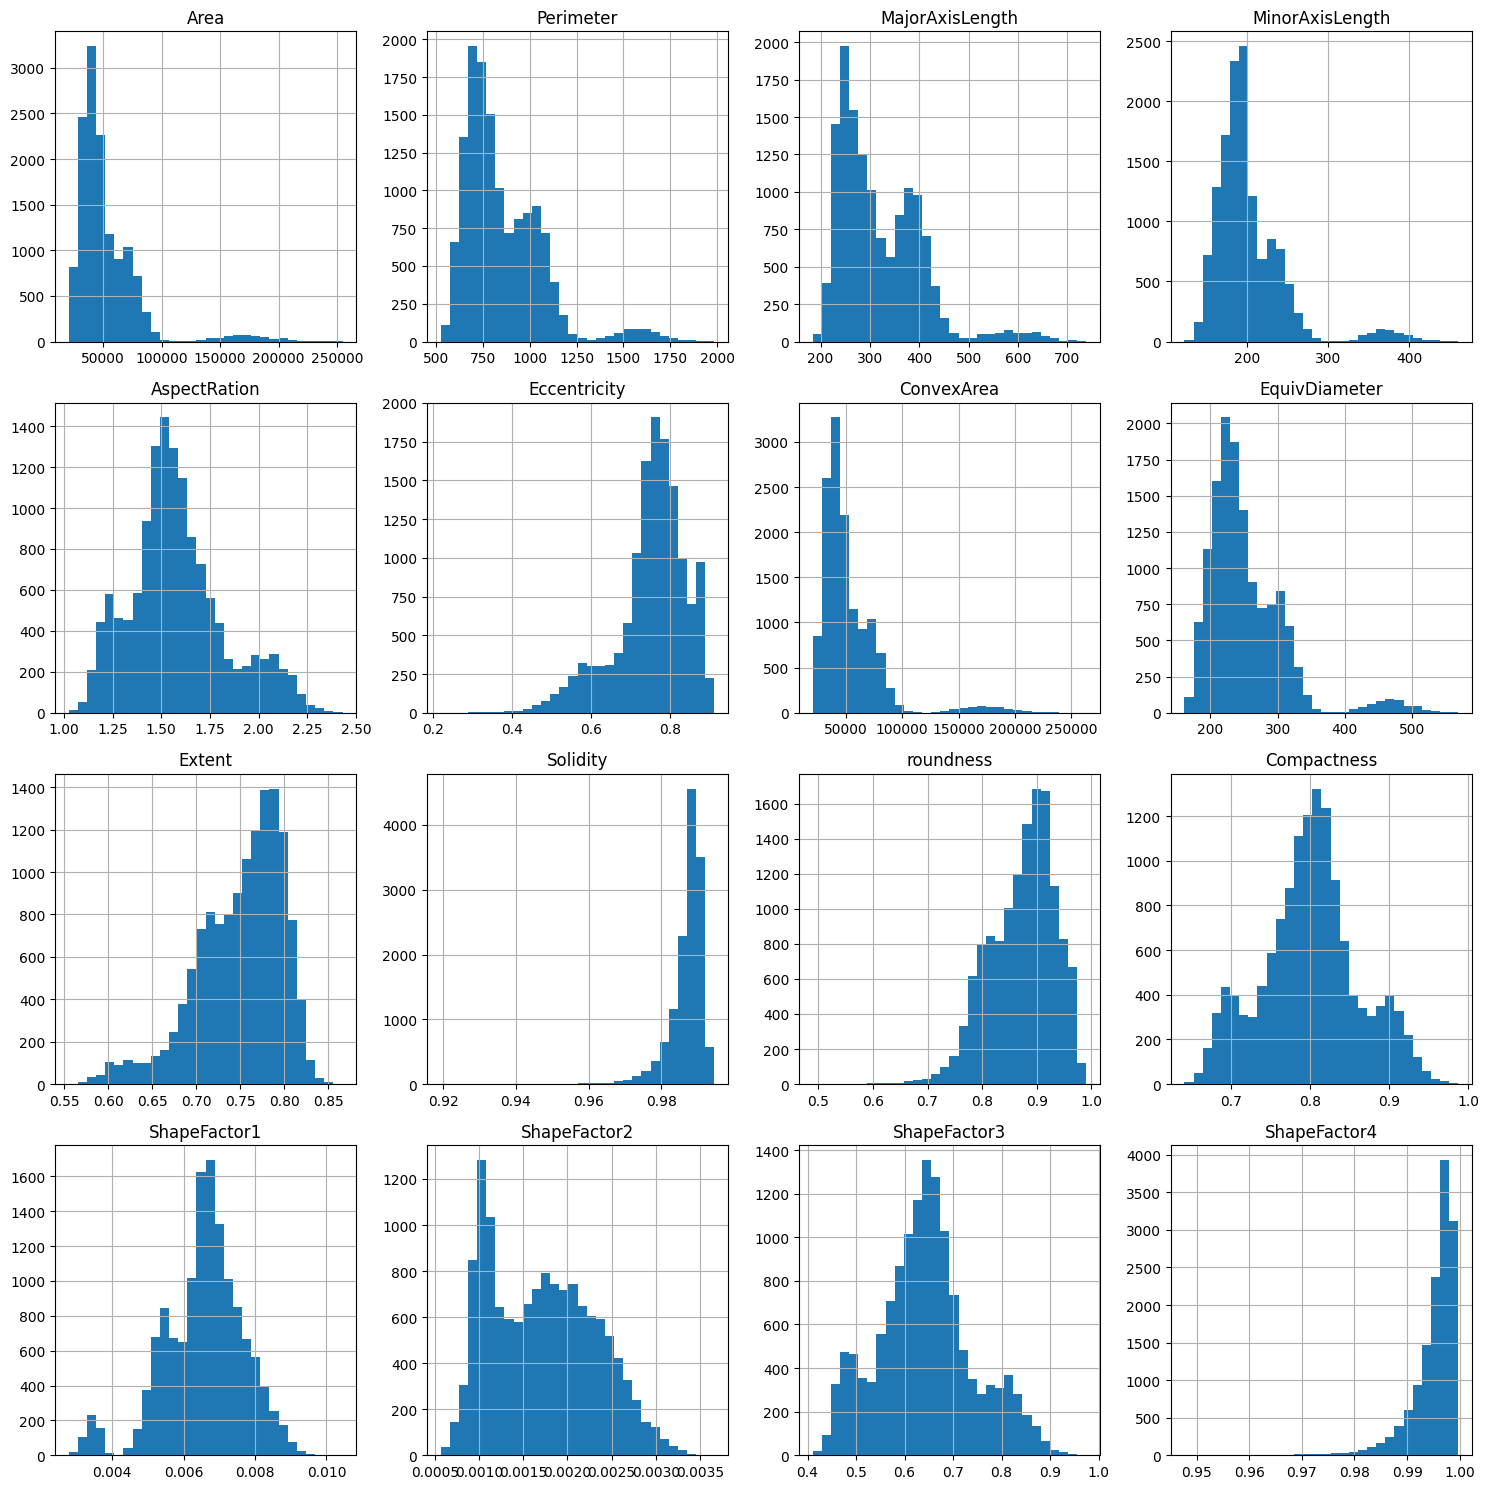

In [15]:
df.hist(bins=30, figsize=(15, 15), layout=(4, 4))
plt.tight_layout()
plt.show()

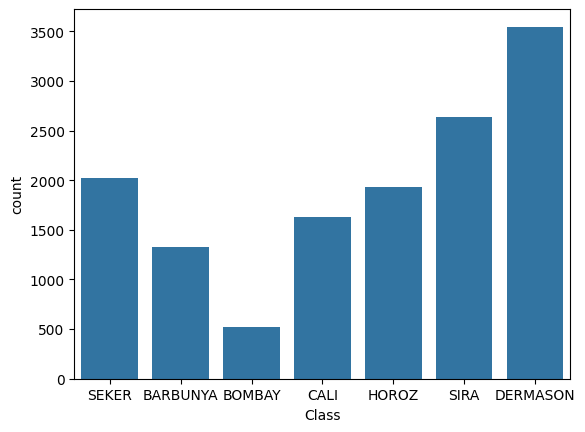

In [16]:
sns.countplot(data=df, x='Class')
plt.show()

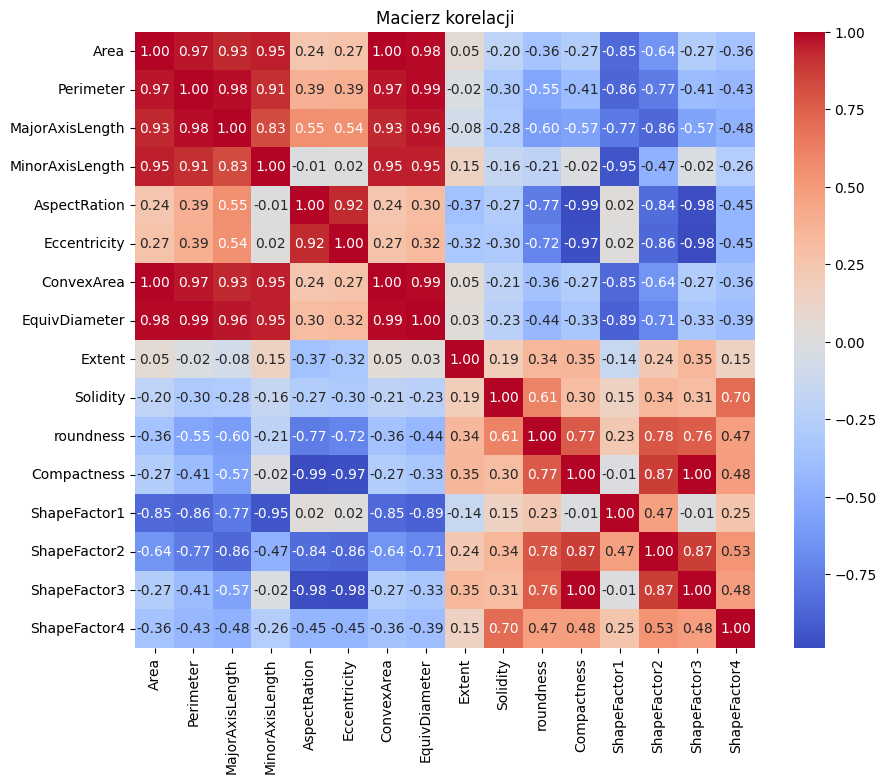

In [17]:
# macierz korelacji
corr_matrix = numerical_df.corr()

# wizualizacja macierzy korelacji
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Macierz korelacji")
plt.show()

In [18]:
Y = df['Class']
X = df.drop(columns=['Class'])

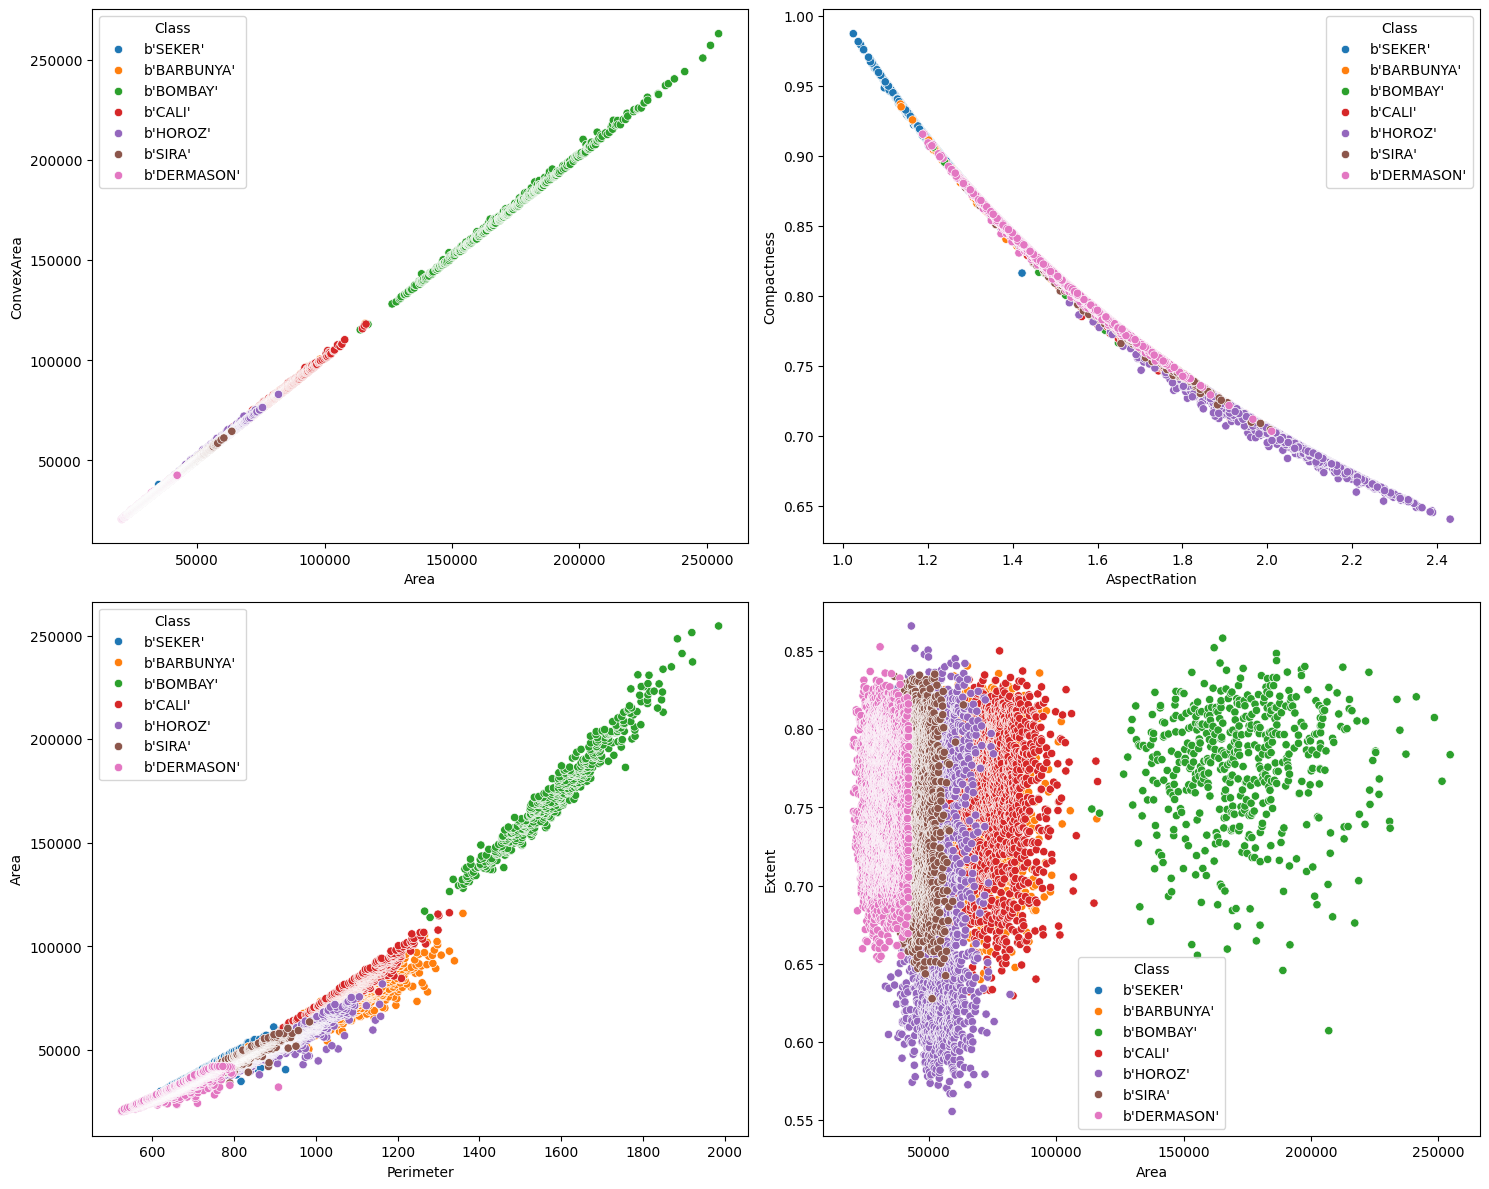

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

sns.scatterplot(data=df, x='Area', y='ConvexArea', hue='Class', ax=axes[0, 0])
sns.scatterplot(data=df, x='AspectRation', y='Compactness', hue='Class', ax=axes[0, 1])
sns.scatterplot(data=df, x='Perimeter', y='Area', hue='Class', ax=axes[1,0])
sns.scatterplot(data=df, x='Area', y='Extent', hue='Class', ax=axes[1,1])

plt.tight_layout()
plt.show()


Cechy do odrzucenia:
- ConvexArea, EquivDiameter (zostaje Area) - mówią o wielkości fasoli
- Eccentricity (zostaje AspectRation) - opisują podobne zjawisko
- ShapeFactor3 (Compactness) - korelacja 1.0 - mówią o tym samym
- Perimeter (zostaje Area i dłu + szer) - zbyt duże korelacje, po co nam 4 miary opisujące wielkość
- AspectRation (Compactness) - korelacja na poziomie -0.99

In [20]:
# usunięcie zbyt skorelowanych cech
X = X.drop(columns=['Perimeter', 'AspectRation', 'ConvexArea', 'EquivDiameter', 'Eccentricity', 'ShapeFactor3'])

corr_matrix = X.corr()

<Axes: >

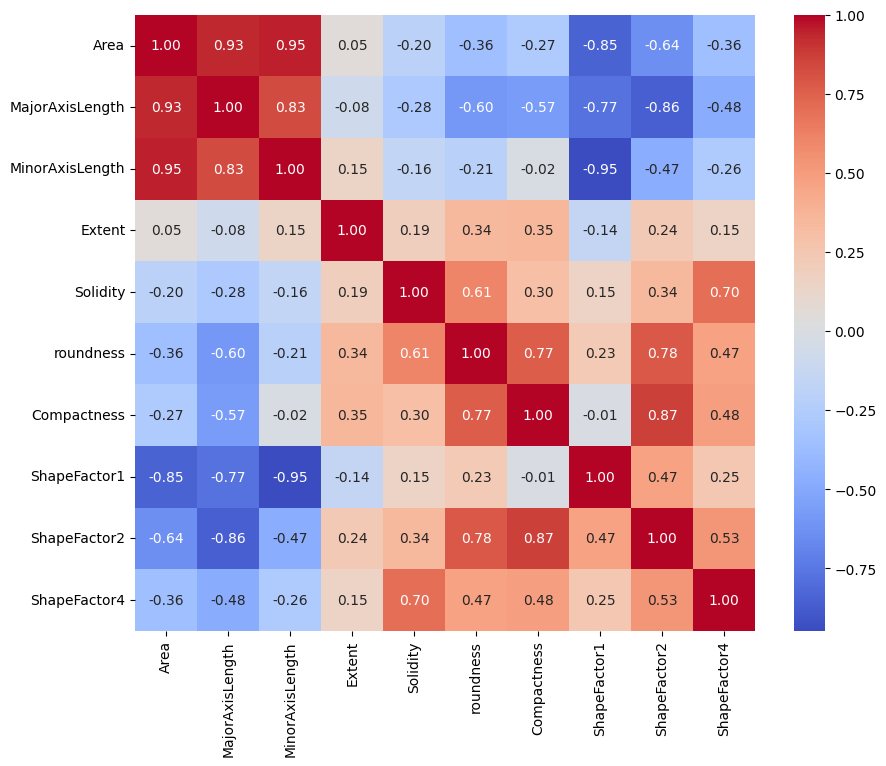

In [21]:
# wizualizacja macierzy korelacji
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")

In [26]:
# STANDARYZACJA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

df = pd.DataFrame(X_scaled, columns=X.columns)

## 2 Algorytm k-średnich

### 2.1 Przygotowanie
Uruchom algorytm k-średnich (sklearn.cluster.KMeans, 4) na przetworzonym zbiorze
danych. Na ten moment przyjmij dowolną liczbę k. Odczytaj wartość miary inercji grupowania.
Opracuj funkcję do wizualizacji wyniku klasteryzacji; możesz posłużyć się przykładami
z tutorialu, ale zadbaj o dopasowanie ich do zbioru danych użytego w tej części listy (patrz:
sekcja o analizie danych).

In [32]:
k = 4
kmeans = KMeans(n_clusters=k)
cluster_labels = kmeans.fit_predict(df)

inercja = kmeans.inertia_
print(f"Wartość miary inercji dla k={k}: {inercja}")

Wartość miary inercji dla k=4: 57149.72575987182
